## Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Membaca file gambar
img = cv2.imread("nama.jpg")

In [3]:
# Melihat dimensi gambar
img.shape

(720, 1280, 3)

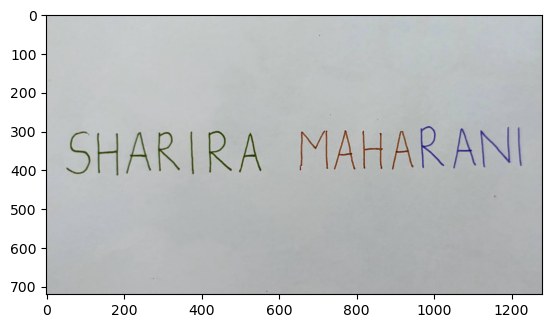

In [4]:
# Menampilkan gambar asli menggunakan plt
plt.imshow(img)

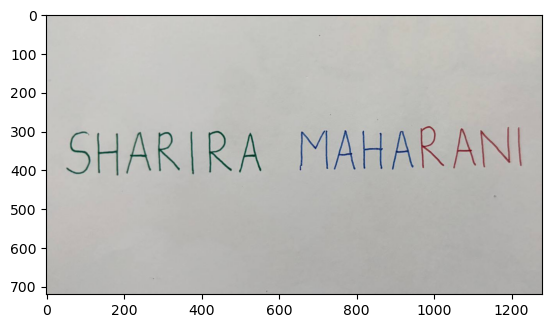

In [5]:
# Konversi gambar asli ke rgb dan menampilkannya
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb)

In [6]:
# Deklarasi variabel baru untuk setiap channel warna
r = rgb[:, :, 0]
g = rgb[:, :, 1]
b = rgb[:, :, 2]

Text(0.5, 1.0, 'Deteksi Biru')

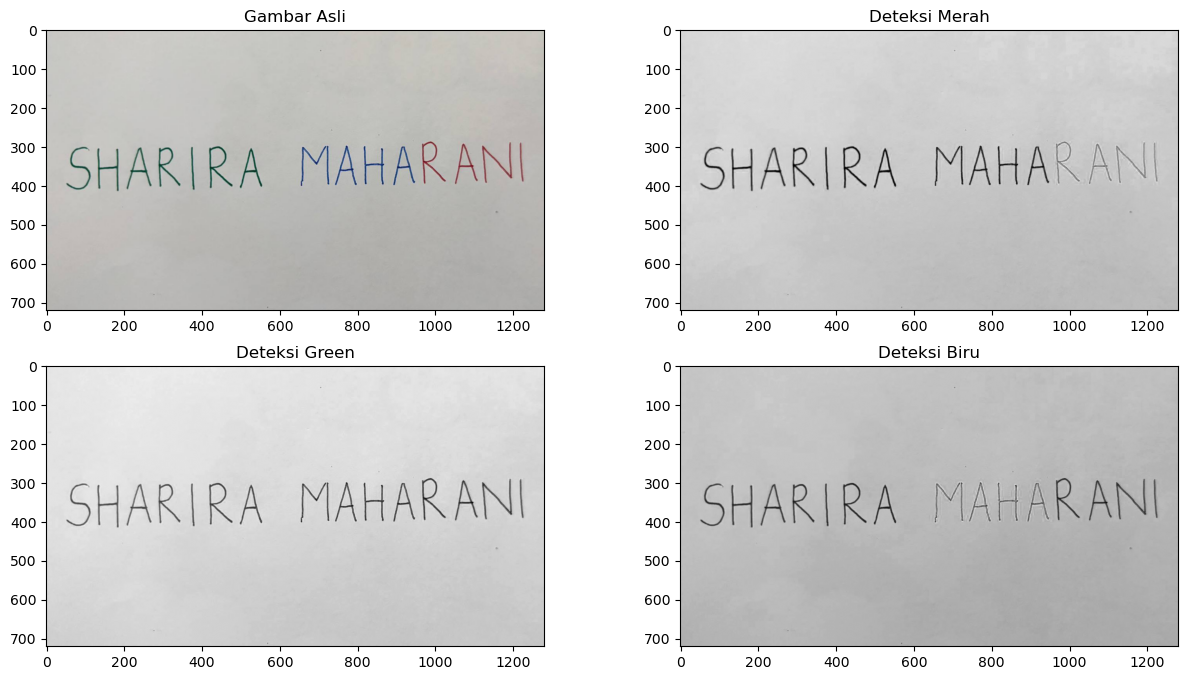

In [7]:
# Menampilkan hasil setiap warna

fig, axs = plt.subplots(2,2, figsize=(15,8))

axs[0,0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0,0].set_title('Gambar Asli')

axs[0,1].imshow(r, cmap="gray")
axs[0,1].set_title('Deteksi Merah')

axs[1,0].imshow(g, cmap="gray")
axs[1,0].set_title('Deteksi Green')

axs[1,1].imshow(b, cmap="gray")
axs[1,1].set_title('Deteksi Biru')

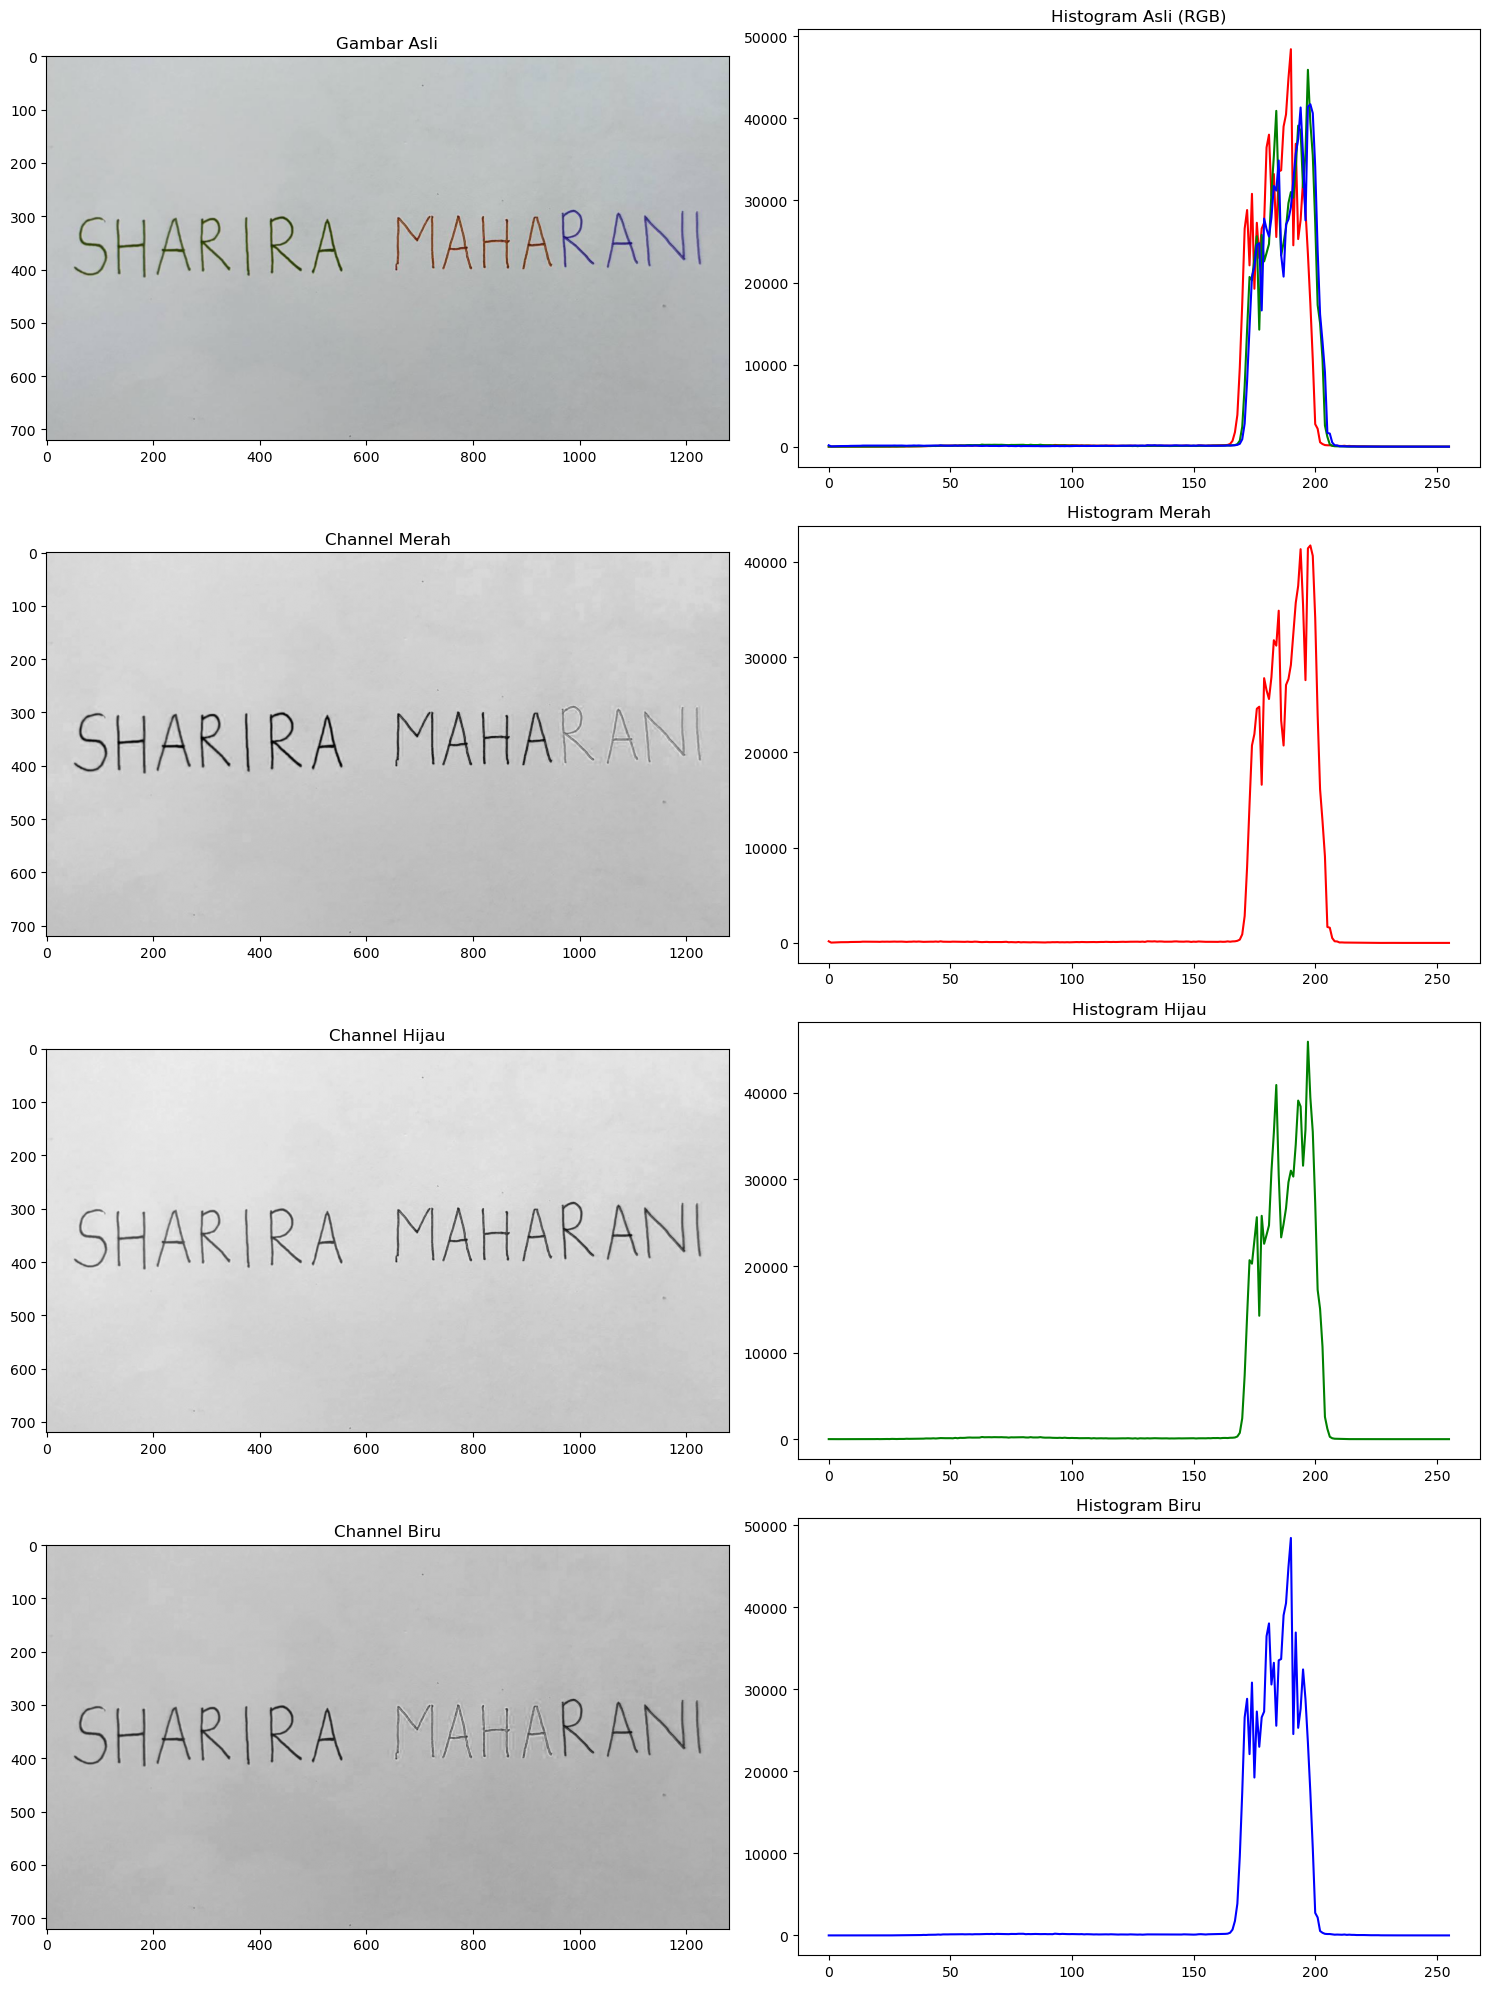

In [8]:
fig, axs = plt.subplots(4, 2, figsize=(15, 20))

hist_asli_r = cv2.calcHist([img], [0], None, [256], [0, 256])
hist_asli_g = cv2.calcHist([img], [1], None, [256], [0, 256])
hist_asli_b = cv2.calcHist([img], [2], None, [256], [0, 256])

axs[0, 0].imshow(img)
axs[0, 0].set_title('Gambar Asli')
axs[0, 1].plot(hist_asli_r, color='r')
axs[0, 1].plot(hist_asli_g, color='g')
axs[0, 1].plot(hist_asli_b, color='b')
axs[0, 1].set_title('Histogram Asli (RGB)')

hist_r = cv2.calcHist([r], [0], None, [256], [0, 256])
axs[1, 0].imshow(r, cmap='gray')
axs[1, 0].set_title('Channel Merah')
axs[1, 1].plot(hist_r, color='r')
axs[1, 1].set_title('Histogram Merah')

hist_g = cv2.calcHist([g], [0], None, [256], [0, 256])
axs[2, 0].imshow(g, cmap='gray')
axs[2, 0].set_title('Channel Hijau')
axs[2, 1].plot(hist_g, color='g')
axs[2, 1].set_title('Histogram Hijau')

hist_b = cv2.calcHist([b], [0], None, [256], [0, 256])
axs[3, 0].imshow(b, cmap='gray')
axs[3, 0].set_title('Channel Biru')
axs[3, 1].plot(hist_b, color='b')
axs[3, 1].set_title('Histogram Biru')

plt.tight_layout()
plt.show()

## Nilai Ambang Batas

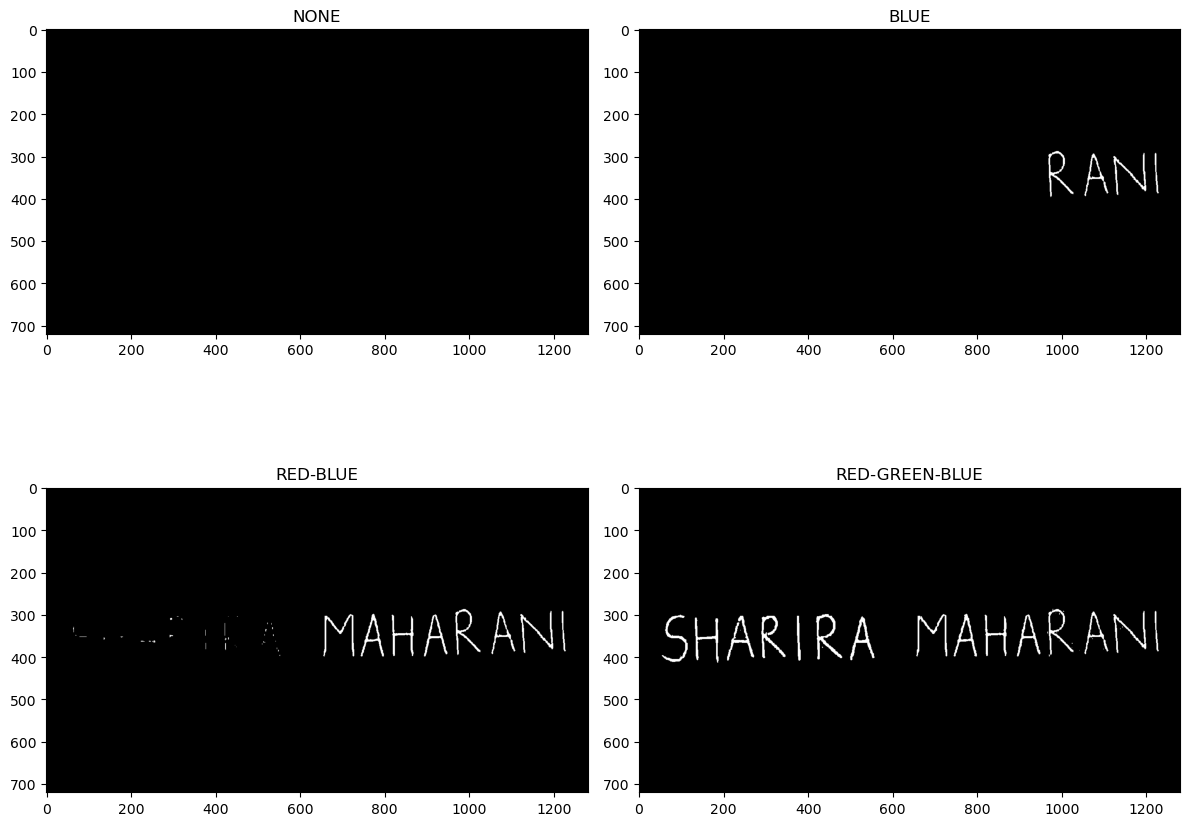

In [9]:
# Memisahkan channel warna menjadi tiga
b, g, r = cv2.split(img)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Mengisolasi bagian merah
selisih_merah = cv2.subtract(r, g)
_, hasil_merah = cv2.threshold(selisih_merah, 40, 255, cv2.THRESH_BINARY)

# Mengisolasi bagian biru
selisih_biru = cv2.subtract(b, r)
_, hasil_biru = cv2.threshold(selisih_biru, 40, 255, cv2.THRESH_BINARY)

# Mengisolasi bagian hijau
selisih_hijau = cv2.subtract(g, r)
_, hasil_hijau = cv2.threshold(selisih_hijau, 18, 255, cv2.THRESH_BINARY)

# NONE (Hitam)
hitam_polos = np.zeros_like(r)
axs[0,0].imshow(hitam_polos, cmap='gray')
axs[0,0].set_title('NONE')

# BLUE 
axs[0,1].imshow(hasil_merah, cmap='gray')
axs[0,1].set_title('BLUE')

# RED-BLUE
gabung_merah_biru = cv2.bitwise_or(hasil_merah, hasil_biru)
axs[1,0].imshow(gabung_merah_biru, cmap='gray')
axs[1,0].set_title('RED-BLUE')

# RED-GREEN-BLUE
semua_warna = cv2.bitwise_or(gabung_merah_biru, hasil_hijau)
axs[1,1].imshow(semua_warna, cmap='gray')
axs[1,1].set_title('RED-GREEN-BLUE')

plt.tight_layout()
plt.show()

# Operasi Pixel

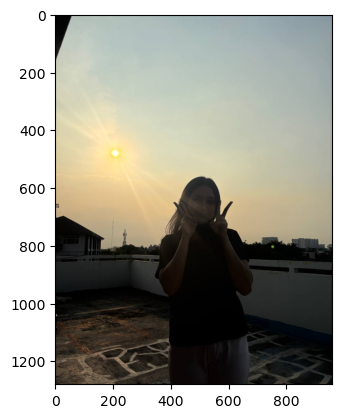

In [10]:
image = cv2.imread("myself.jpg")
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)

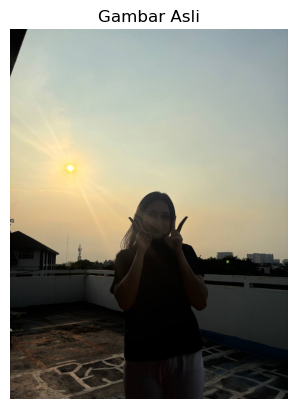

In [11]:
# Menampilkan Gambar Asli
plt.imshow(rgb_image)
plt.title("Gambar Asli")
plt.axis("off")
plt.show()

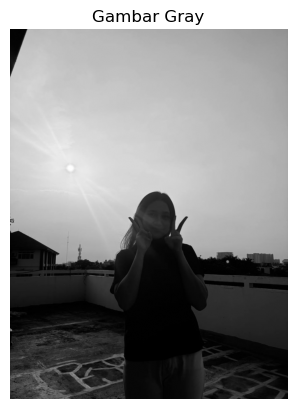

In [12]:
# Menampilkan Gambar Abu
gambar_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gambar_gray, cmap = 'gray')
plt.title("Gambar Gray")
plt.axis("off")
plt.show()

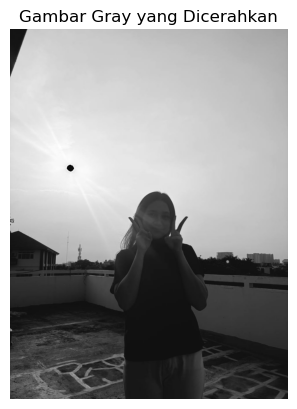

In [13]:
# Membuat Gambar Abu yang dicerahkan
[baris, kolom] = gambar_gray.shape[:2]

beta = 16.5
gambar_cerah = np.zeros((baris, kolom, 3))

for x in range(baris):
    for y in range(kolom):
        gyx = gambar_gray[x,y] + beta
        gambar_cerah[x,y] = gyx

gambar_cerah = gambar_cerah.astype(np.uint8)

plt.imshow(gambar_cerah, cmap='gray')
plt.title("Gambar Gray yang Dicerahkan")
plt.axis("off")
plt.show()

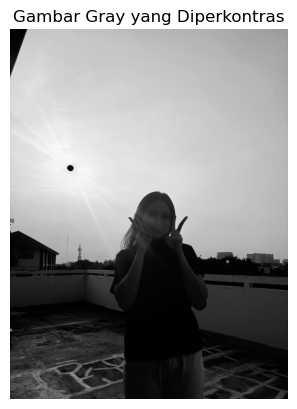

In [14]:
# Membuat Gambar abu yang di kontraskan
alpha = 1.06
gambar_kontras = np.zeros((baris, kolom, 3))

for x in range(baris):
    for y in range(kolom):
        gyx = gambar_gray[x,y] * alpha
        gambar_kontras[x,y] = gyx

gambar_kontras = gambar_kontras.astype(np.uint8)

plt.imshow(gambar_kontras, cmap='gray')
plt.title("Gambar Gray yang Diperkontras")
plt.axis("off")
plt.show()

C:\Users\shari\AppData\Local\Temp\ipykernel_26072\3581203818.py:8: RuntimeWarning: overflow encountered in scalar add
  gyx = alpha * gambar_gray[x,y] + beta


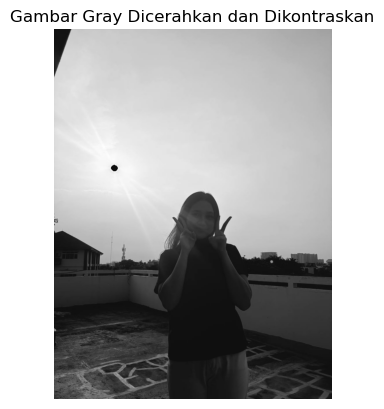

In [15]:
# Membuat gambar abu yang dipercerah dan dikontraskan
beta = 15
alpha = 1
gambar_hasil = np.zeros((baris, kolom, 3))

for x in range(baris):
    for y in range(kolom):
        gyx = alpha * gambar_gray[x,y] + beta
        gambar_hasil[x,y] = gyx

gambar_hasil = gambar_hasil.astype(np.uint8)

plt.imshow(gambar_hasil, cmap='gray')
plt.title("Gambar Gray Dicerahkan dan Dikontraskan")
plt.axis("off")
plt.show()

Text(0.5, 1.0, 'Gambar Gray yang Dicerahkan dan Dikontraskan')

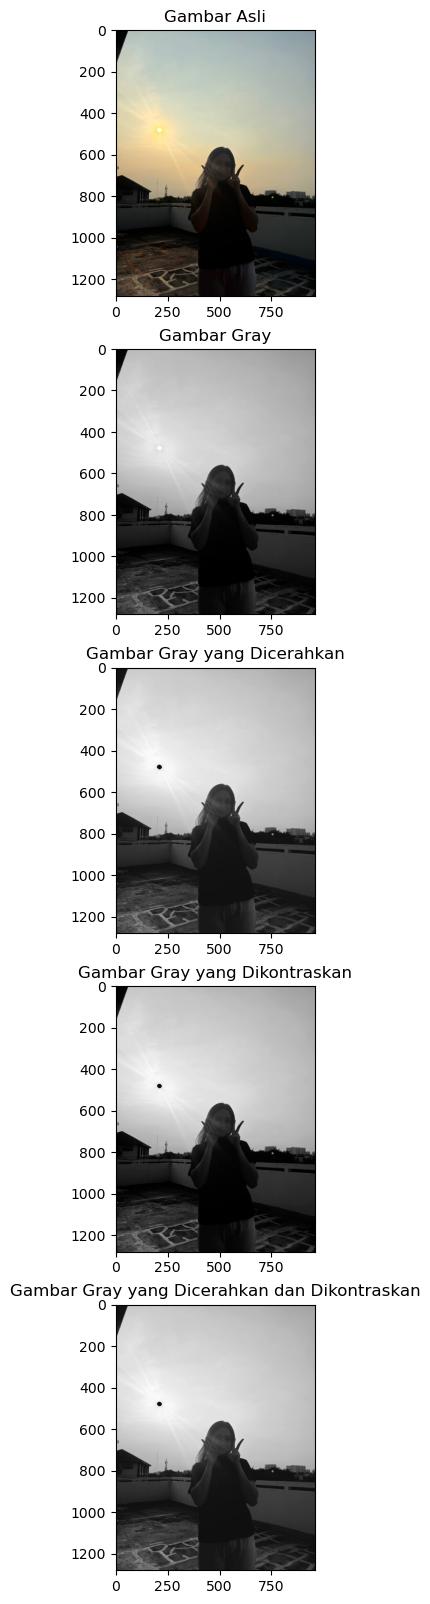

In [16]:
# Menampilkan semua hasil gambar

fig, axs = plt.subplots(5, figsize=(10,20))
axs[0].imshow(rgb_image)
axs[0].set_title('Gambar Asli')

axs[1].imshow(gambar_gray, cmap='gray')
axs[1].set_title('Gambar Gray')

axs[2].imshow(gambar_cerah, cmap='gray')
axs[2].set_title('Gambar Gray yang Dicerahkan')

axs[3].imshow(gambar_kontras, cmap='gray')
axs[3].set_title('Gambar Gray yang Dikontraskan')

axs[4].imshow(gambar_hasil, cmap='gray')
axs[4].set_title('Gambar Gray yang Dicerahkan dan Dikontraskan')